Cell 1 — Imports and Canvas Setup

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider, Dropdown, Checkbox, Text
from minicv.drawing import draw_line, draw_rectangle, draw_polygon, draw_text, draw_point

Cell 2 — Interactive Point Drawing 

In [ ]:
@interact(
    mode=Dropdown(options=['RGB', 'Grayscale'], value='RGB'),
    x=IntSlider(min=-100, max=600, value=250),
    y=IntSlider(min=-100, max=600, value=250),
    thickness=IntSlider(min=1, max=150, value=40),
    r=(0, 255), g=(0, 255), b=(0, 255),
    intensity=IntSlider(min=0, max=255, value=200)
)
def interactive_point(mode, x, y, thickness, r, g, b, intensity):
    if mode == 'RGB':
        canvas = np.zeros((500, 500, 3), dtype=np.uint8)
        color = (r, g, b)
        label = f"RGB ({r},{g},{b})"
    else:
        canvas = np.zeros((500, 500), dtype=np.uint8)
        color = intensity
        label = f"Gray intensity={intensity}"

    draw_point(canvas, x, y, color=color, thickness=thickness)

    plt.figure(figsize=(6, 6))
    plt.imshow(canvas, cmap='gray' if mode == 'Grayscale' else None, vmin=0, vmax=255)
    plt.axvline(0, color='red', linestyle='--', alpha=0.4, label='Canvas edge')
    plt.axhline(0, color='red', linestyle='--', alpha=0.4)
    plt.title(f"draw_point | pos=({x},{y}) | thickness={thickness} | {label}")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

interactive(children=(Dropdown(description='mode', options=('RGB', 'Grayscale'), value='RGB'), IntSlider(value…

Cell 3 — Interactive Line Drawing 

In [5]:
@interact(
    x0=IntSlider(min=-50, max=550, value=50),
    y0=IntSlider(min=-50, max=550, value=50),
    x1=IntSlider(min=-50, max=550, value=450),
    y1=IntSlider(min=-50, max=550, value=400),
    thickness=IntSlider(min=1, max=15, value=2),
    r=(0, 255), g=(0, 255), b=(0, 255)
)
def interactive_line(x0, y0, x1, y1, thickness, r, g, b):
    canvas = np.zeros((500, 500, 3), dtype=np.uint8)
    draw_line(canvas, x0, y0, x1, y1, color=(r, g, b), thickness=thickness)

    plt.figure(figsize=(7, 7))
    plt.imshow(canvas)
    plt.axvline(0, color='red', linestyle='--', alpha=0.4)
    plt.axhline(0, color='red', linestyle='--', alpha=0.4)
    plt.title(f"draw_line (Bresenham) | ({x0},{y0}) -> ({x1},{y1}) | thickness={thickness}")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

interactive(children=(IntSlider(value=50, description='x0', max=550, min=-50), IntSlider(value=50, description…

Cell 4 — Interactive Rectangle Drawing

In [6]:
@interact(
    x0=IntSlider(min=-100, max=499, value=100),
    y0=IntSlider(min=-100, max=499, value=100),
    x1=IntSlider(min=0,    max=600, value=400),
    y1=IntSlider(min=0,    max=600, value=350),
    thickness=IntSlider(min=1, max=10, value=3),
    filled=Checkbox(value=True, description='Filled'),
    r=(0, 255), g=(0, 255), b=(0, 255)
)
def interactive_rectangle(x0, y0, x1, y1, thickness, filled, r, g, b):
    canvas = np.zeros((500, 500, 3), dtype=np.uint8)

    if x0 >= x1 or y0 >= y1:
        plt.figure(figsize=(7, 7))
        plt.imshow(canvas)
        plt.title("Invalid: x0 must be < x1 and y0 must be < y1", color='red')
        plt.axis("off")
        plt.tight_layout()
        plt.show()
        return

    draw_rectangle(canvas, x0, y0, x1, y1,
                   color=(r, g, b), thickness=thickness, filled=filled)

    plt.figure(figsize=(7, 7))
    plt.imshow(canvas)
    plt.axvline(0, color='red', linestyle='--', alpha=0.4)
    plt.axhline(0, color='red', linestyle='--', alpha=0.4)
    plt.title(f"draw_rectangle | ({x0},{y0})->({x1},{y1}) | filled={filled} | thickness={thickness}")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

interactive(children=(IntSlider(value=100, description='x0', max=499, min=-100), IntSlider(value=100, descript…

Cell 5 — The Polygon Cell

In [ ]:
@interact(
    mode=Dropdown(options=['RGB', 'Grayscale'], value='RGB'),
    num_vertices=IntSlider(min=3, max=12, step=1, value=3, description='Vertices'),
    radius=IntSlider(min=50, max=250, value=150, description='Size'),
    v1_x=IntSlider(min=-100, max=600, value=250, description='Center X'),
    v1_y=IntSlider(min=-100, max=600, value=250, description='Center Y'),
    filled=Checkbox(value=True, description='Filled'),
    thickness=IntSlider(min=1, max=10, value=2),
    r=(0, 255), g=(0, 255), b=(0, 255),
    intensity=IntSlider(min=0, max=255, value=200)
)
def interactive_polygon(mode, num_vertices, radius, v1_x, v1_y, filled, thickness, r, g, b, intensity):
    if mode == 'RGB':
        canvas = np.zeros((500, 500, 3), dtype=np.uint8)
        color = (r, g, b)
    else:
        canvas = np.zeros((500, 500), dtype=np.uint8)
        color = intensity

    # Generate points for a regular polygon centered at (v1_x, v1_y)
    pts = []
    for i in range(num_vertices):
        # Calculate angle for each vertex in radians
        angle = 2 * np.pi * i / num_vertices - np.pi / 2  # Subtract pi/2 to point upwards
        x = v1_x + radius * np.cos(angle)
        y = v1_y + radius * np.sin(angle)
        pts.append((int(x), int(y)))

    draw_polygon(canvas, pts, color=color, thickness=thickness, filled=filled)

    plt.figure(figsize=(6, 6))
    plt.imshow(canvas, cmap='gray' if mode == 'Grayscale' else None, vmin=0, vmax=255)
    plt.title(f"n={num_vertices} Polygon | center=({v1_x},{v1_y}) | filled={filled}")
    plt.axis("off")
    plt.show()

interactive(children=(Dropdown(description='mode', options=('RGB', 'Grayscale'), value='RGB'), IntSlider(value…

Cell 6 — Interactive Text

In [ ]:
@interact(
    mode=Dropdown(options=['RGB', 'Grayscale'], value='RGB'),
    message=Text(value='HELLO', description='Text:'),
    scale=IntSlider(min=1, max=10, value=3),
    x=IntSlider(min=-100, max=500, value=50),
    y=IntSlider(min=-100, max=500, value=200),
    intensity=(0, 255)
)
def interactive_text(mode, message, scale, x, y, intensity):
    if mode == 'RGB':
        canvas = np.zeros((500, 500, 3), dtype=np.uint8)
        color = (intensity, 255, 255 - intensity)
    else:
        canvas = np.zeros((500, 500), dtype=np.uint8)
        color = intensity

    draw_text(canvas, message.upper(), x, y, color=color, scale=scale)

    plt.figure(figsize=(10, 6))
    plt.imshow(canvas, cmap='gray' if mode == 'Grayscale' else None, vmin=0, vmax=255)
    plt.axvline(0, color='red', linestyle='--', alpha=0.4)
    plt.axhline(0, color='red', linestyle='--', alpha=0.4)
    plt.title(f"draw_text | scale={scale} | pos=({x},{y}) | mode={mode}")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

interactive(children=(Dropdown(description='mode', options=('RGB', 'Grayscale'), value='RGB'), Text(value='HEL…

Cell 7 — Boundary Clipping Stress Test

In [ ]:
@interact(
    offset_x=IntSlider(min=-300, max=300, step=10, value=0),
    offset_y=IntSlider(min=-300, max=300, step=10, value=0)
)
def test_clipping(offset_x, offset_y):
    canvas = np.zeros((500, 500, 3), dtype=np.uint8)

    x0 = 150 + offset_x
    y0 = 150 + offset_y
    x1 = 350 + offset_x
    y1 = 350 + offset_y

    status = "OK — clipped to canvas"
    if x0 >= x1 or y0 >= y1:
        status = "Skipped — degenerate rectangle (x0>=x1 or y0>=y1)"
    else:
        draw_rectangle(canvas, x0, y0, x1, y1, color=(0, 255, 100), filled=True)

    plt.figure(figsize=(7, 7))
    plt.imshow(canvas)
    plt.axhline(0, color='red', linestyle='--', alpha=0.5, label='Canvas edge')
    plt.axvline(0, color='red', linestyle='--', alpha=0.5)
    plt.title(f"Clipping test | rect=({x0},{y0})->({x1},{y1})\n{status}")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

interactive(children=(IntSlider(value=0, description='offset_x', max=300, min=-300, step=10), IntSlider(value=…

Cell 8 — combined showcase (all primitives on one canvas)

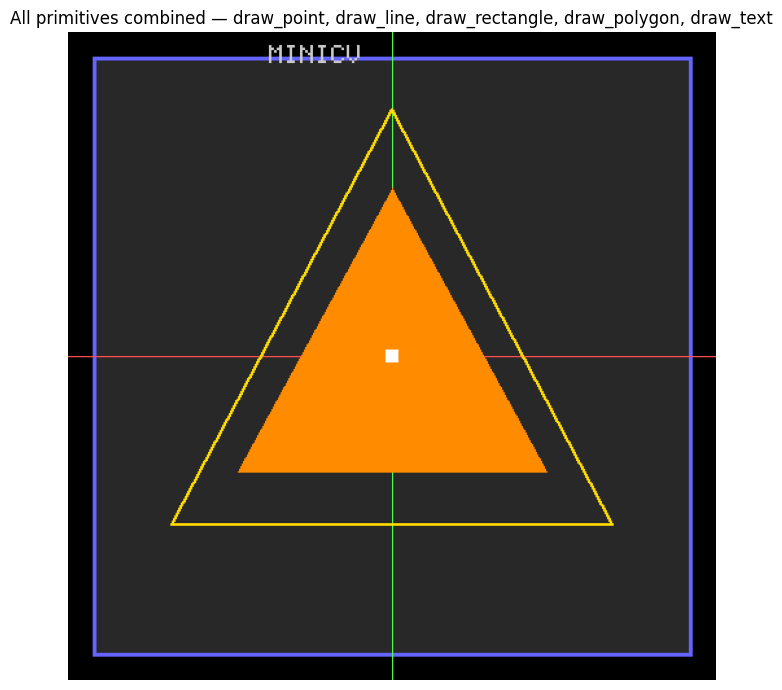

In [11]:
canvas = np.zeros((500, 500, 3), dtype=np.uint8)

draw_rectangle(canvas, 20,  20,  480, 480, color=(40, 40, 40),    filled=True)
draw_rectangle(canvas, 20,  20,  480, 480, color=(100, 100, 255), filled=False, thickness=3)
draw_line(canvas, 0, 250, 500, 250, color=(255, 80, 80),  thickness=1)
draw_line(canvas, 250, 0, 250, 500, color=(80, 255, 80),  thickness=1)
draw_polygon(canvas, [(250,60),(420,380),(80,380)],
             color=(255, 220, 0), thickness=2, filled=False)
draw_polygon(canvas, [(250,120),(370,340),(130,340)],
             color=(255, 140, 0), filled=True)
draw_point(canvas, 250, 250, color=(255, 255, 255), thickness=10)
draw_text(canvas, "minicv", x=155, y=10, color=(200, 200, 200), scale=2)

plt.figure(figsize=(7, 7))
plt.imshow(canvas)
plt.title("All primitives combined — draw_point, draw_line, draw_rectangle, draw_polygon, draw_text")
plt.axis("off")
plt.tight_layout()
plt.show()